In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.impute import SimpleImputer

from sklearn.cluster import KMeans, AgglomerativeClustering
from sklearn.metrics import silhouette_score

from sklearn.decomposition import PCA

from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier

from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    classification_report, confusion_matrix, ConfusionMatrixDisplay
)

from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping


In [2]:
df = pd.read_csv("Global_Pollution_Analysis.csv")

print("Shape:", df.shape)
df.head()


Shape: (200, 13)


,Country,Year,Air_Pollution_Index,Water_Pollution_Index,Soil_Pollution_Index,Industrial_Waste (in tons),Energy_Recovered (in GWh),CO2_Emissions (in MT),Renewable_Energy (%),Plastic_Waste_Produced (in tons),Energy_Consumption_Per_Capita (in MWh),Population (in millions),GDP_Per_Capita (in USD)
0,Hungary,2005,272.70,124.27,51.95,94802.83,158.14,5.30,41.11,37078.88,12.56,42.22,20972.96
1,Singapore,2001,86.72,60.34,117.22,56283.92,498.04,6.34,36.44,33128.20,5.23,137.25,34850.41
2,Romania,2016,91.59,83.36,121.72,56256.02,489.51,49.69,9.38,18803.46,13.15,124.47,57773.15
3,Cook Islands,2018,280.61,67.16,93.58,74864.73,145.18,8.91,18.97,9182.27,0.78,67.80,21837.51
4,Djibouti,2008,179.16,127.53,121.55,76862.06,40.38,14.93,34.00,39235.12,12.84,186.52,41379.37


In [3]:
df.columns = df.columns.str.strip()
df.columns.tolist()
df.isnull().sum().sort_values(ascending=False)


Country                                   0
Year                                      0
Air_Pollution_Index                       0
Water_Pollution_Index                     0
Soil_Pollution_Index                      0
Industrial_Waste (in tons)                0
Energy_Recovered (in GWh)                 0
CO2_Emissions (in MT)                     0
Renewable_Energy (%)                      0
Plastic_Waste_Produced (in tons)          0
Energy_Consumption_Per_Capita (in MWh)    0
Population (in millions)                  0
GDP_Per_Capita (in USD)                   0
dtype: int64

In [4]:
air_col = "Air_Pollution_Index"
water_col = "Water_Pollution_Index"
soil_col = "Soil_Pollution_Index"

df["Pollution_Index"] = df[[air_col, water_col, soil_col]].mean(axis=1)

df[["Pollution_Index", air_col, water_col, soil_col]].head()


,Pollution_Index,Air_Pollution_Index,Water_Pollution_Index,Soil_Pollution_Index
0,149.640000,272.70,124.27,51.95
1,88.093333,86.72,60.34,117.22
2,98.890000,91.59,83.36,121.72
3,147.116667,280.61,67.16,93.58
4,142.746667,179.16,127.53,121.55


In [5]:
energy_pc_col = "Energy_Consumption_Per_Capita (in MWh)"
population_col = "Population (in millions)"

df["Energy_Consumption_Per_Capita"] = df[energy_pc_col]
df["Population"] = df[population_col] * 1_000_000  # converting millions to actual population

df[["Energy_Consumption_Per_Capita", "Population"]].head()

df["Total_Energy_Consumption_MWh"] = df["Energy_Consumption_Per_Capita"] * df["Population"]
df[["Total_Energy_Consumption_MWh"]].head()


,Total_Energy_Consumption_MWh
0,5.302832e+08
1,7.178175e+08
2,1.636780e+09
3,5.288400e+07
4,2.394917e+09


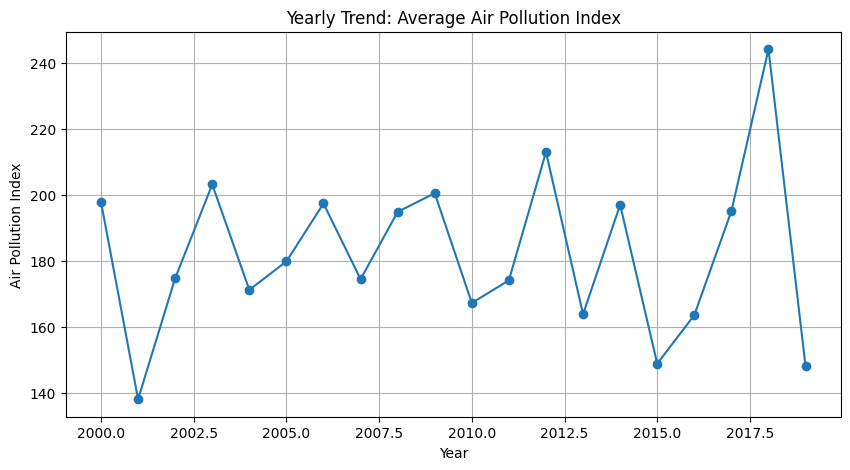

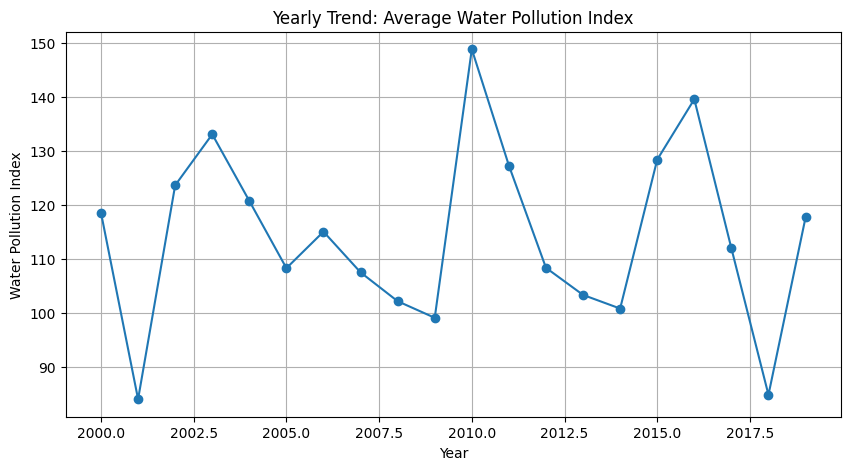

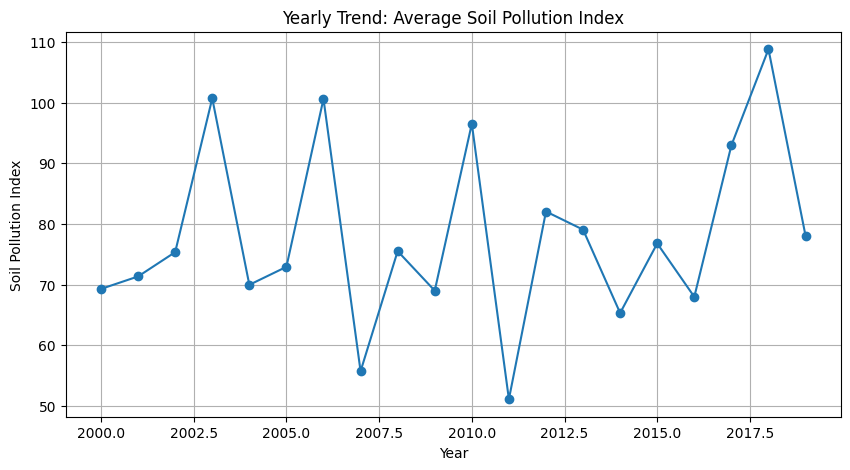

In [6]:
#Air Pollution Trend Over Years
plt.figure(figsize=(10,5))
df.groupby("Year")[air_col].mean().plot(marker="o")
plt.title("Yearly Trend: Average Air Pollution Index")
plt.xlabel("Year")
plt.ylabel("Air Pollution Index")
plt.grid(True)
plt.show()

#Water Pollution Trend Over Years
plt.figure(figsize=(10,5))
df.groupby("Year")[water_col].mean().plot(marker="o")
plt.title("Yearly Trend: Average Water Pollution Index")
plt.xlabel("Year")
plt.ylabel("Water Pollution Index")
plt.grid(True)
plt.show()

#soil Pollution Trend Over Years
plt.figure(figsize=(10,5))
df.groupby("Year")[soil_col].mean().plot(marker="o")
plt.title("Yearly Trend: Average Soil Pollution Index")
plt.xlabel("Year")
plt.ylabel("Soil Pollution Index")
plt.grid(True)
plt.show()



In [9]:
df["Pollution_Severity"] = pd.qcut(df["Pollution_Index"], q=3, labels=["Low", "Medium", "High"])
df["Pollution_Severity"].value_counts()

severity_map = {"Low": 0, "Medium": 1, "High": 2}
df["Pollution_Severity_Label"] = df["Pollution_Severity"].map(severity_map)

df[["Pollution_Severity", "Pollution_Severity_Label"]].head()

,Pollution_Severity,Pollution_Severity_Label
0,High,2
1,Low,0
2,Low,0
3,High,2
4,High,2


In [10]:
features = [
    air_col, water_col, soil_col,
    "Energy_Consumption_Per_Capita",
    "Total_Energy_Consumption_MWh",
    "Pollution_Index"
]

# Only keep features that exist to avoid errors
features = [c for c in features if c in df.columns]

X_cls = df[features].copy()
y_cls = df["Pollution_Severity_Label"].copy()

# Handle missing
imputer = SimpleImputer(strategy="median")
X_cls_imputed = imputer.fit_transform(X_cls)

# Scale
scaler = StandardScaler()
X_cls_scaled = scaler.fit_transform(X_cls_imputed)

print("X_cls shape:", X_cls_scaled.shape)
print("y_cls shape:", y_cls.shape)


X_cls shape: (200, 6)
y_cls shape: (200,)


In [11]:
X_train, X_test, y_train, y_test = train_test_split(
    X_cls_scaled, y_cls,
    test_size=0.2,
    random_state=42,
    stratify=y_cls
)

print("Train:", X_train.shape, y_train.shape)
print("Test :", X_test.shape, y_test.shape)


Train: (160, 6) (160,)
Test : (40, 6) (40,)


In [13]:

lr_model = LogisticRegression(max_iter=2000)  

lr_model.fit(X_train, y_train)

y_pred_lr = lr_model.predict(X_test)

print("Logistic Regression Accuracy:", accuracy_score(y_test, y_pred_lr))
print(classification_report(y_test, y_pred_lr, target_names=["Low", "Medium", "High"]))



Logistic Regression Accuracy: 0.9
              precision    recall  f1-score   support

         Low       0.93      0.93      0.93        14
      Medium       0.85      0.85      0.85        13
        High       0.92      0.92      0.92        13

    accuracy                           0.90        40
   macro avg       0.90      0.90      0.90        40
weighted avg       0.90      0.90      0.90        40



In [14]:
knn_model = KNeighborsClassifier(n_neighbors=5)
knn_model.fit(X_train, y_train)

y_pred_knn = knn_model.predict(X_test)

print("KNN Accuracy:", accuracy_score(y_test, y_pred_knn))
print(classification_report(y_test, y_pred_knn, target_names=["Low", "Medium", "High"]))


KNN Accuracy: 0.85
              precision    recall  f1-score   support

         Low       0.86      0.86      0.86        14
      Medium       0.73      0.85      0.79        13
        High       1.00      0.85      0.92        13

    accuracy                           0.85        40
   macro avg       0.86      0.85      0.85        40
weighted avg       0.86      0.85      0.85        40



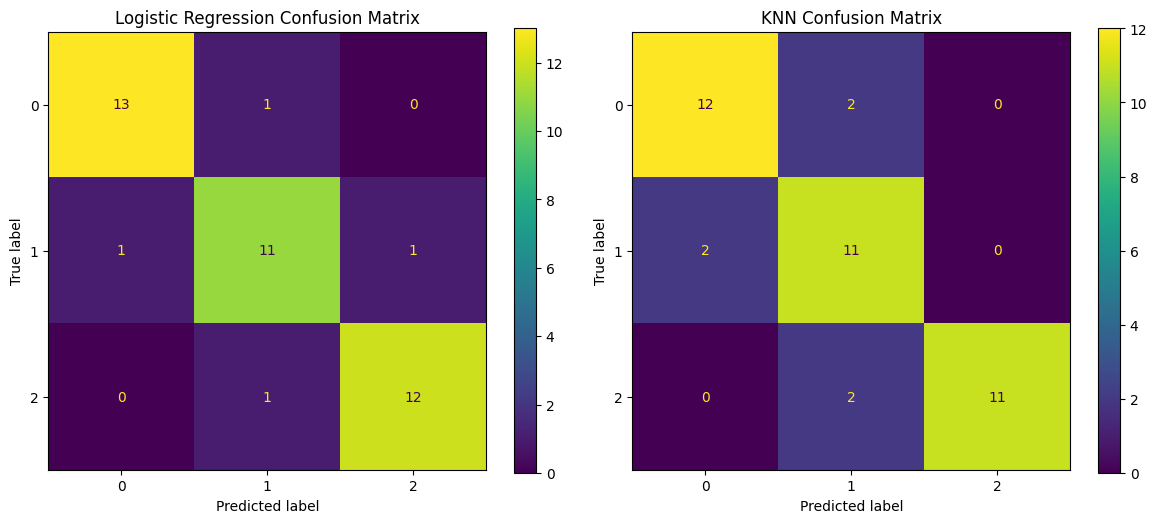

In [15]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

ConfusionMatrixDisplay.from_predictions(y_test, y_pred_lr, ax=axes[0])
axes[0].set_title("Logistic Regression Confusion Matrix")

ConfusionMatrixDisplay.from_predictions(y_test, y_pred_knn, ax=axes[1])
axes[1].set_title("KNN Confusion Matrix")

plt.tight_layout()
plt.show()


In [16]:
cluster_features = [
    air_col, water_col, soil_col,
    "Energy_Consumption_Per_Capita",
    "Pollution_Index"
]
cluster_features = [c for c in cluster_features if c in df.columns]

X_cluster = df[cluster_features].copy()

X_cluster_imputed = imputer.fit_transform(X_cluster)
X_cluster_scaled = scaler.fit_transform(X_cluster_imputed)

print("X_cluster shape:", X_cluster_scaled.shape)


X_cluster shape: (200, 5)


In [17]:
kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
df["KMeans_Cluster"] = kmeans.fit_predict(X_cluster_scaled)

sil_kmeans = silhouette_score(X_cluster_scaled, df["KMeans_Cluster"])
print("KMeans Silhouette Score:", sil_kmeans)


KMeans Silhouette Score: 0.2049923605966985


In [18]:
agglo = AgglomerativeClustering(n_clusters=3)
df["Hierarchical_Cluster"] = agglo.fit_predict(X_cluster_scaled)

sil_agglo = silhouette_score(X_cluster_scaled, df["Hierarchical_Cluster"])
print("Hierarchical Silhouette Score:", sil_agglo)


Hierarchical Silhouette Score: 0.1621914278568638


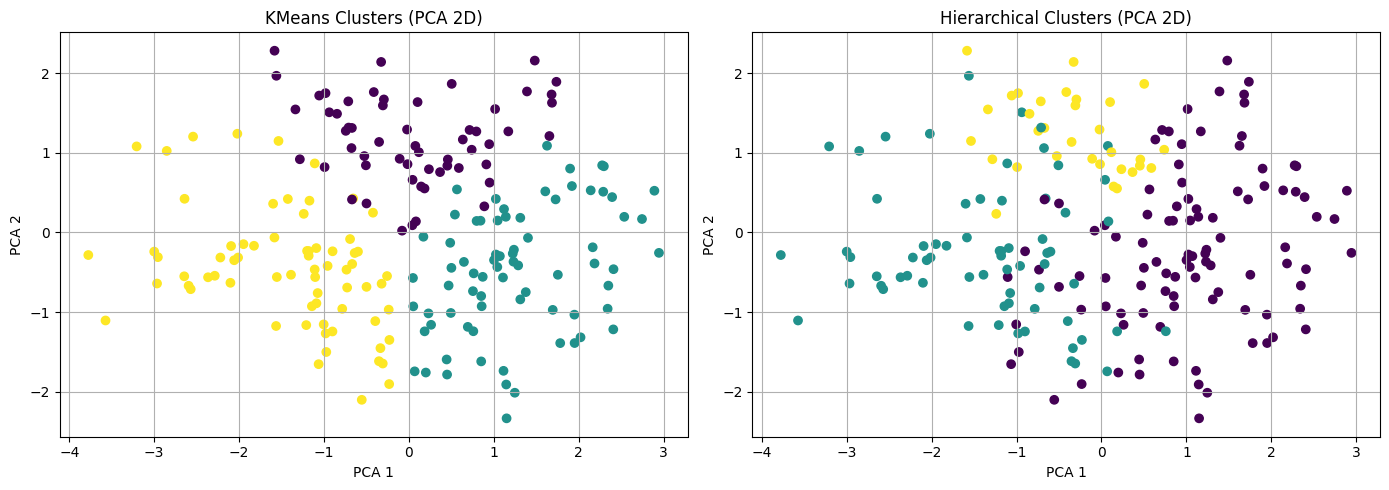

In [19]:
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_cluster_scaled)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].scatter(X_pca[:, 0], X_pca[:, 1], c=df["KMeans_Cluster"])
axes[0].set_title("KMeans Clusters (PCA 2D)")
axes[0].set_xlabel("PCA 1")
axes[0].set_ylabel("PCA 2")
axes[0].grid(True)

axes[1].scatter(X_pca[:, 0], X_pca[:, 1], c=df["Hierarchical_Cluster"])
axes[1].set_title("Hierarchical Clusters (PCA 2D)")
axes[1].set_xlabel("PCA 1")
axes[1].set_ylabel("PCA 2")
axes[1].grid(True)

plt.tight_layout()
plt.show()


In [20]:
df.columns.tolist()
target_col = "Energy_Recovered (in GWh)"


In [21]:
target_col = "Energy_Recovered (in GWh)"

X_reg = df[cluster_features].copy()
y_reg = df[target_col].copy()

X_reg_imputed = imputer.fit_transform(X_reg)
X_reg_scaled = scaler.fit_transform(X_reg_imputed)

y_reg = y_reg.fillna(y_reg.median())

Xr_train, Xr_test, yr_train, yr_test = train_test_split(
    X_reg_scaled, y_reg,
    test_size=0.2,
    random_state=42
)

print("Regression Train:", Xr_train.shape, yr_train.shape)
print("Regression Test :", Xr_test.shape, yr_test.shape)


Regression Train: (160, 5) (160,)
Regression Test : (40, 5) (40,)


In [22]:
lin_reg = LinearRegression()
lin_reg.fit(Xr_train, yr_train)

y_pred_lin = lin_reg.predict(Xr_test)

print("Linear Regression Results")
print("R2:", r2_score(yr_test, y_pred_lin))
print("MSE:", mean_squared_error(yr_test, y_pred_lin))
print("MAE:", mean_absolute_error(yr_test, y_pred_lin))


Linear Regression Results
R2: -0.0759445875287792
MSE: 26018.746554454625
MAE: 144.3030122090934


In [23]:
def build_nn(hidden1=64, hidden2=32, dropout=0.2, lr=0.001):
    model = Sequential([
        Dense(hidden1, activation="relu", input_shape=(Xr_train.shape[1],)),
        Dropout(dropout),
        Dense(hidden2, activation="relu"),
        Dropout(dropout),
        Dense(1)  # regression output
    ])
    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=lr),
        loss="mse",
        metrics=["mae"]
    )
    return model


In [25]:
param_list = [
    {"hidden1": 64, "hidden2": 32, "dropout": 0.2, "lr": 0.001},
    {"hidden1": 128, "hidden2": 64, "dropout": 0.3, "lr": 0.001},
    {"hidden1": 128, "hidden2": 32, "dropout": 0.4, "lr": 0.0005},
]

best_r2 = -999
best_model = None
best_params = None

early_stop = EarlyStopping(monitor="val_loss", patience=5, restore_best_weights=True)

for params in param_list:
    model = build_nn(**params)
    model.fit(
        Xr_train, yr_train,
        validation_split=0.2,
        epochs=50,
        batch_size=32,
        callbacks=[early_stop],
        verbose=0
    )
    
    pred = model.predict(Xr_test).ravel()
    r2 = r2_score(yr_test, pred)
    
    print("Params:", params, "| R2:", r2)
    
    if r2 > best_r2:
        best_r2 = r2
        best_model = model
        best_params = params

print("Best NN Params:", best_params)
print("Best NN R2:", best_r2)


d:\ML course\.venv\Lib\site-packages\keras\src\layers\core\dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step
Params: {'hidden1': 64, 'hidden2': 32, 'dropout': 0.2, 'lr': 0.001} | R2: -1.1254753139217866


d:\ML course\.venv\Lib\site-packages\keras\src\layers\core\dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step
Params: {'hidden1': 128, 'hidden2': 64, 'dropout': 0.3, 'lr': 0.001} | R2: -2.358777137610679


d:\ML course\.venv\Lib\site-packages\keras\src\layers\core\dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step
Params: {'hidden1': 128, 'hidden2': 32, 'dropout': 0.4, 'lr': 0.0005} | R2: -2.3640885808196
Best NN Params: {'hidden1': 64, 'hidden2': 32, 'dropout': 0.2, 'lr': 0.001}
Best NN R2: -1.1254753139217866


In [26]:
y_pred_nn = best_model.predict(Xr_test).ravel()

print("Best Neural Network Results")
print("R2:", r2_score(yr_test, y_pred_nn))
print("MSE:", mean_squared_error(yr_test, y_pred_nn))
print("MAE:", mean_absolute_error(yr_test, y_pred_nn))


2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step
Best Neural Network Results
R2: -1.1254753139217866
MSE: 51398.7468701325
MAE: 182.5546175994873


In [27]:
comparison_table = pd.DataFrame({
    "Task": ["Clustering", "Clustering", "Regression", "Regression"],
    "Model": ["KMeans", "Hierarchical", "Linear Regression", "Neural Network (Tuned)"],
    "Metric": ["Silhouette Score", "Silhouette Score", "R2 Score", "R2 Score"],
    "Score": [sil_kmeans, sil_agglo, r2_score(yr_test, y_pred_lin), r2_score(yr_test, y_pred_nn)]
})

comparison_table


,Task,Model,Metric,Score
0,Clustering,KMeans,Silhouette Score,0.204992
1,Clustering,Hierarchical,Silhouette Score,0.162191
2,Regression,Linear Regression,R2 Score,-0.075945
3,Regression,Neural Network (Tuned),R2 Score,-1.125475


Summary Report
 
In this assignment, I worked on the Global Pollution Analysis dataset to build a complete workflow that includes trend analysis, clustering, classification, and regression. I first cleaned and prepared the dataset by handling missing values, scaling numerical features, and engineering important variables such as the overall **Pollution_Index** (computed using Air, Water, and Soil Pollution Indices) and **Energy Consumption per Capita** for deeper environmental analysis. To address pollution trends clearly, I separately visualized and interpreted the **yearly trends of Air, Water, and Soil pollution indices**, instead of only analyzing overall pollution. I then created a **Pollution Severity** target (Low, Medium, High) using quantile-based binning and performed machine learning classification using **Logistic Regression and KNN**, evaluating both models using accuracy, precision, recall, F1-score, and side-by-side confusion matrix visualizations for a clear comparison. For unsupervised learning, I applied both **K-Means and Hierarchical clustering**, compared their cluster structures using PCA-based visualizations, and measured cluster quality quantitatively using **Silhouette Scores**. In addition, I performed regression to predict energy recovery using a **Linear Regression baseline** and a **Neural Network**, and I improved the neural network performance through hyperparameter tuning by adjusting layers, neurons, dropout, learning rate, and early stopping. Finally, I provided a quantitative comparison across tasks by reporting clustering metrics (Silhouette Scores) and regression metrics (R², MSE, MAE) to connect clustering outcomes and predictive performance in a measurable way. Overall, this assignment demonstrates a complete and validated analysis pipeline that links pollution indicators with energy recovery insights while supporting both interpretability and performance-based decision-making.
